# Support Vector Machine (SVM)

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
## Lets create synthetic datapoints
from sklearn.datasets import make_classification

In [3]:
X,y=make_classification(n_samples=1000,n_features=2,n_classes=2,n_clusters_per_class=1,n_redundant=0, random_state=4)
y[:5]

array([1, 1, 1, 1, 1])

In [4]:
X=pd.DataFrame(X)
X.head()

,0,1
0,1.225160,-0.951731
1,1.016304,-1.725175
2,0.335340,-1.724896
3,1.786348,-1.782653
4,1.016751,1.062569


<Axes: xlabel='0', ylabel='1'>

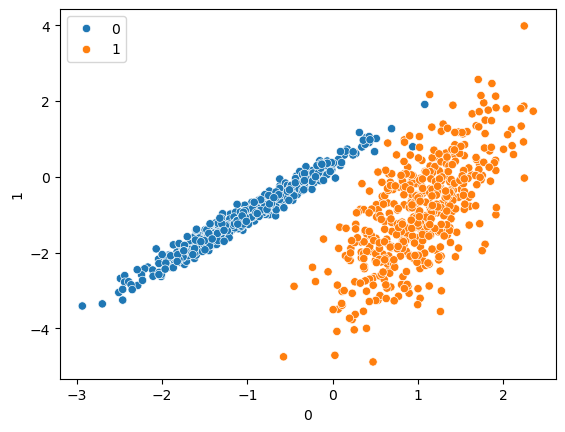

In [5]:
sns.scatterplot(x=X[0],y=X[1],hue=y)

We can use SVC to classify this data. The kernel will be linear

In [6]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=10)

In [7]:
from sklearn.svm import SVC

svc=SVC(kernel='linear')
svc.fit(X_train,y_train)

SVC(kernel='linear')

In [8]:
## Predictio

y_pred=svc.predict(X_test)

In [9]:
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score

score=accuracy_score(y_test,y_pred)
print(score)
cm=confusion_matrix(y_test,y_pred)
print(cm)
print(classification_report(y_test,y_pred))

1.0
[[123   0]
 [  0 127]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       123
           1       1.00      1.00      1.00       127

    accuracy                           1.00       250
   macro avg       1.00      1.00      1.00       250
weighted avg       1.00      1.00      1.00       250



### Other Kernels

When the data points cannot be linearly separable we use other kernels like RBF, Sigmoid or Polynomial 




#### **RBF kernel**

In [10]:
## create a binary classification dataset with multiple clusters

X,y=make_classification(n_samples=1000,n_features=2,n_classes=2,n_clusters_per_class=2,n_redundant=0, random_state=33)
y[:5]

array([1, 0, 0, 0, 1])

In [11]:
X=pd.DataFrame(X)
X.head()

,0,1
0,-1.125785,0.890510
1,-0.964564,-1.461033
2,2.726490,0.243033
3,-0.641874,-0.257132
4,1.007173,0.989763


<Axes: xlabel='0', ylabel='1'>

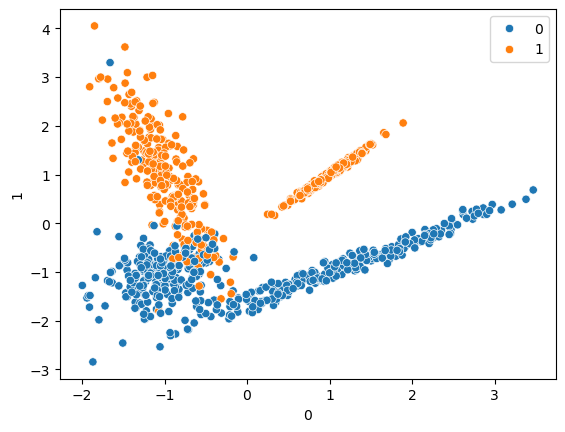

In [12]:
sns.scatterplot(x=X[0],y=X[1],hue=y)

In [13]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=10)

In [14]:
from sklearn.svm import SVC

rbf=SVC(kernel='rbf')
rbf.fit(X_train,y_train)

SVC()

In [15]:
y_pred=rbf.predict(X_test)

In [16]:
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score

score=accuracy_score(y_test,y_pred)
print(score)
cm=confusion_matrix(y_test,y_pred)
print(cm)
print(classification_report(y_test,y_pred))

0.94
[[121   5]
 [ 10 114]]
              precision    recall  f1-score   support

           0       0.92      0.96      0.94       126
           1       0.96      0.92      0.94       124

    accuracy                           0.94       250
   macro avg       0.94      0.94      0.94       250
weighted avg       0.94      0.94      0.94       250



#### **Polynomial Kernel**

In [17]:
polynomial=SVC(kernel='poly')
polynomial.fit(X_train,y_train)

SVC(kernel='poly')

In [18]:
y_pred2=polynomial.predict(X_test)

score=accuracy_score(y_test,y_pred2)
print(score)
cm=confusion_matrix(y_test,y_pred2)
print(cm)
print(classification_report(y_test,y_pred2))

0.948
[[119   7]
 [  6 118]]
              precision    recall  f1-score   support

           0       0.95      0.94      0.95       126
           1       0.94      0.95      0.95       124

    accuracy                           0.95       250
   macro avg       0.95      0.95      0.95       250
weighted avg       0.95      0.95      0.95       250



#### **Sigmoid Kernel***

In [19]:
sigmoid=SVC(kernel='sigmoid')
sigmoid.fit(X_train,y_train)

SVC(kernel='sigmoid')

In [20]:
y_pred3=sigmoid.predict(X_test)

score=accuracy_score(y_test,y_pred3)
print(score)
cm=confusion_matrix(y_test,y_pred3)
print(cm)
print(classification_report(y_test,y_pred3))

0.92
[[119   7]
 [ 13 111]]
              precision    recall  f1-score   support

           0       0.90      0.94      0.92       126
           1       0.94      0.90      0.92       124

    accuracy                           0.92       250
   macro avg       0.92      0.92      0.92       250
weighted avg       0.92      0.92      0.92       250



### Performing Hyperparameter Tuning 

Based on the models created Polynomial kernel gave us the best performance. We will perform some hyperparameter tuning to see if we can improve the model performance.

In [21]:
from sklearn.model_selection import GridSearchCV

## defining parameter range
param_grid={'C':[0.1,1,10,100,1000],
            'gamma':[1,0.1,0.01,0.001,0.0001],
            'kernel':['poly']}

In [22]:
grid=GridSearchCV(SVC(),param_grid=param_grid,cv=5,verbose=3,refit=True)

In [23]:
grid.fit(X_train,y_train)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
[CV 1/5] END .......C=0.1, gamma=1, kernel=poly;, score=0.960 total time=   0.0s
[CV 2/5] END .......C=0.1, gamma=1, kernel=poly;, score=0.960 total time=   0.0s
[CV 3/5] END .......C=0.1, gamma=1, kernel=poly;, score=0.933 total time=   0.0s
[CV 4/5] END .......C=0.1, gamma=1, kernel=poly;, score=0.960 total time=   0.0s
[CV 5/5] END .......C=0.1, gamma=1, kernel=poly;, score=0.953 total time=   0.0s
[CV 1/5] END .....C=0.1, gamma=0.1, kernel=poly;, score=0.727 total time=   0.0s
[CV 2/5] END .....C=0.1, gamma=0.1, kernel=poly;, score=0.667 total time=   0.0s
[CV 3/5] END .....C=0.1, gamma=0.1, kernel=poly;, score=0.720 total time=   0.0s
[CV 4/5] END .....C=0.1, gamma=0.1, kernel=poly;, score=0.673 total time=   0.0s
[CV 5/5] END .....C=0.1, gamma=0.1, kernel=poly;, score=0.713 total time=   0.0s
[CV 1/5] END ....C=0.1, gamma=0.01, kernel=poly;, score=0.540 total time=   0.0s
[CV 2/5] END ....C=0.1, gamma=0.01, kernel=poly

GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [0.1, 1, 10, 100, 1000],
                         'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
                         'kernel': ['poly']},
             verbose=3)

In [24]:
grid.best_params_

{'C': 1, 'gamma': 1, 'kernel': 'poly'}

In [25]:
grid.best_score_

0.9560000000000001

In [26]:
y_pred_grid=grid.predict(X_test)

score=accuracy_score(y_test,y_pred_grid)
print(score)
cm=confusion_matrix(y_test,y_pred_grid)
print(cm)
print(classification_report(y_test,y_pred_grid))

0.952
[[119   7]
 [  5 119]]
              precision    recall  f1-score   support

           0       0.96      0.94      0.95       126
           1       0.94      0.96      0.95       124

    accuracy                           0.95       250
   macro avg       0.95      0.95      0.95       250
weighted avg       0.95      0.95      0.95       250



Notice It improved from 0.948 to 0.952

### SVM Kernels Indepth Intuition And Practical Explanation

In [51]:
import numpy as np
import matplotlib.pyplot as plt

x=np.linspace(-5.0,5.0,100)
y=np.sqrt(10**2 - x**2)
y=np.hstack([y,-y])
x=np.hstack([x,-x])

In [52]:
x1=np.linspace(-5.0,5.0,100)
y1=np.sqrt(5**2 - x1**2)
y1=np.hstack([y1,-y1])
x1=np.hstack([x1,-x1])

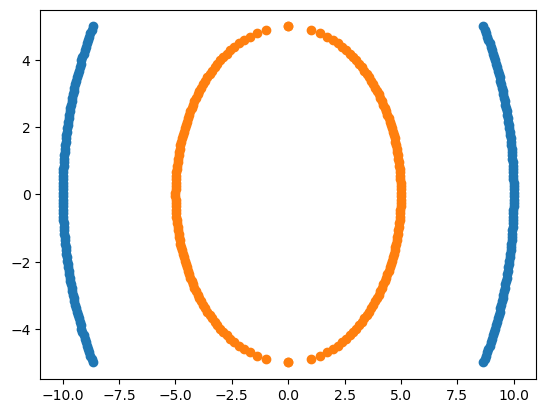

In [53]:
plt.scatter(y,x)
plt.scatter(y1,x1)

Notice you cannot use linear svc to classify this data. We will have to use other kernels.

In [54]:
np.vstack([y,x]).T

array([[ 8.66025404, -5.        ],
       [ 8.71779204, -4.8989899 ],
       [ 8.77378994, -4.7979798 ],
       [ 8.82827705, -4.6969697 ],
       [ 8.88128118, -4.5959596 ],
       [ 8.93282873, -4.49494949],
       [ 8.98294476, -4.39393939],
       [ 9.03165312, -4.29292929],
       [ 9.07897646, -4.19191919],
       [ 9.12493632, -4.09090909],
       [ 9.16955321, -3.98989899],
       [ 9.21284664, -3.88888889],
       [ 9.25483518, -3.78787879],
       [ 9.29553652, -3.68686869],
       [ 9.3349675 , -3.58585859],
       [ 9.37314414, -3.48484848],
       [ 9.41008171, -3.38383838],
       [ 9.44579475, -3.28282828],
       [ 9.4802971 , -3.18181818],
       [ 9.51360192, -3.08080808],
       [ 9.54572176, -2.97979798],
       [ 9.57666854, -2.87878788],
       [ 9.60645359, -2.77777778],
       [ 9.63508769, -2.67676768],
       [ 9.66258107, -2.57575758],
       [ 9.68894344, -2.47474747],
       [ 9.714184  , -2.37373737],
       [ 9.73831149, -2.27272727],
       [ 9.76133416,

In [55]:
import pandas as pd
df1=pd.DataFrame(np.vstack([y,x]).T,columns=['X1','X2'])
df1['Y']=0
df2=pd.DataFrame(np.vstack([y1,x1]).T,columns=['X1','X2'])
df2['Y']=1
df = pd.concat([df1, df2], ignore_index=True)
df.head(5)

,X1,X2,Y
0,8.660254,-5.00000,0
1,8.717792,-4.89899,0
2,8.773790,-4.79798,0
3,8.828277,-4.69697,0
4,8.881281,-4.59596,0


In [56]:
df.tail()

,X1,X2,Y
395,-1.969049,-4.59596,1
396,-1.714198,-4.69697,1
397,-1.406908,-4.79798,1
398,-0.999949,-4.89899,1
399,-0.000000,-5.00000,1


In [57]:
## Independent and Dependent Feature
X=df.iloc[:,:2]
X.head()

,X1,X2
0,8.660254,-5.00000
1,8.717792,-4.89899
2,8.773790,-4.79798
3,8.828277,-4.69697
4,8.881281,-4.59596


In [58]:
y=df['Y']
y.head()

0    0
1    0
2    0
3    0
4    0
Name: Y, dtype: int64

In [59]:
## Split the dataset into train test split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

#### Polynomial Kernel

$$
K(\mathbf{x}, \mathbf{y}) = (\mathbf{x}^{\mathsf{T}}\mathbf{y} + c)^d
$$

In [64]:
df2=df.copy()

In [65]:
df2.head()

,X1,X2,Y
0,8.660254,-5.00000,0
1,8.717792,-4.89899,0
2,8.773790,-4.79798,0
3,8.828277,-4.69697,0
4,8.881281,-4.59596,0


In [66]:
## We need to find some components for the Polynomial Kernel
#X1,X2, X1_square,X2_square,X1*X2
df2['X1_Square']=df2['X1']**2
df2['X2_Square']=df2['X2']**2
df2['X1*X2']=(df2['X1']*df2['X2'])
df2.head()

,X1,X2,Y,X1_Square,X2_Square,X1*X2
0,8.660254,-5.00000,0,75.000000,25.000000,-43.301270
1,8.717792,-4.89899,0,75.999898,24.000102,-42.708375
2,8.773790,-4.79798,0,76.979390,23.020610,-42.096467
3,8.828277,-4.69697,0,77.938476,22.061524,-41.466150
4,8.881281,-4.59596,0,78.877155,21.122845,-40.818009


In [67]:
### Independent and Dependent features for the manual calculations
X2=df2[['X1','X2','X1_Square','X2_Square','X1*X2']]
y2=df2['Y']

In [68]:
y2

0      0
1      0
2      0
3      0
4      0
      ..
395    1
396    1
397    1
398    1
399    1
Name: Y, Length: 400, dtype: int64

In [69]:
## Run the train test split with the adjusted dataframe
X_train2,X_test2,y_train2,y_test2=train_test_split(X2,y2,test_size=0.25,random_state=0)
X_train2

,X1,X2,X1_Square,X2_Square,X1*X2
250,4.999745,0.050505,24.997449,0.002551,0.252512
63,9.906589,1.363636,98.140496,1.859504,13.508984
312,-3.263736,3.787879,10.651974,14.348026,-12.362637
159,-9.953852,-0.959596,99.079176,0.920824,9.551676
283,3.680983,3.383838,13.549638,11.450362,12.455852
...,...,...,...,...,...
323,-4.223140,2.676768,17.834915,7.165085,-11.304366
192,-9.031653,-4.292929,81.570758,18.429242,38.772248
117,-9.445795,3.282828,89.223038,10.776962,-31.008922
47,9.996811,-0.252525,99.936231,0.063769,-2.524447


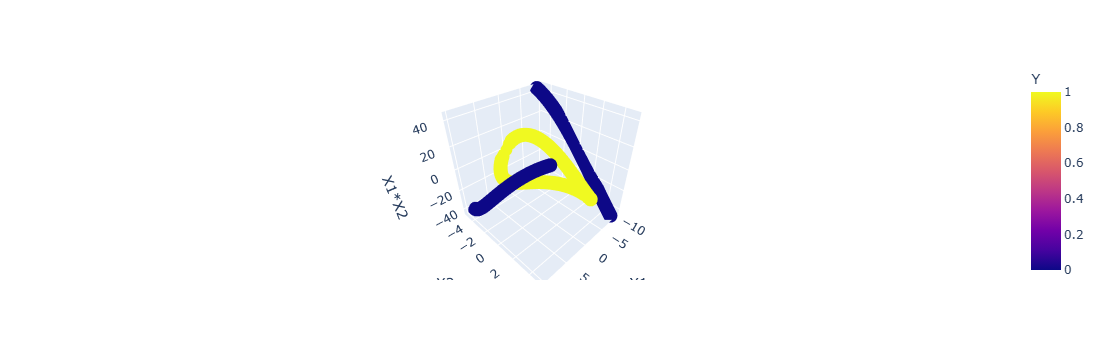

In [70]:
import plotly.express as px

fig=px.scatter_3d(df2,x='X1',y='X2',z='X1*X2', color='Y')

fig.show()

It is still not linearly separable

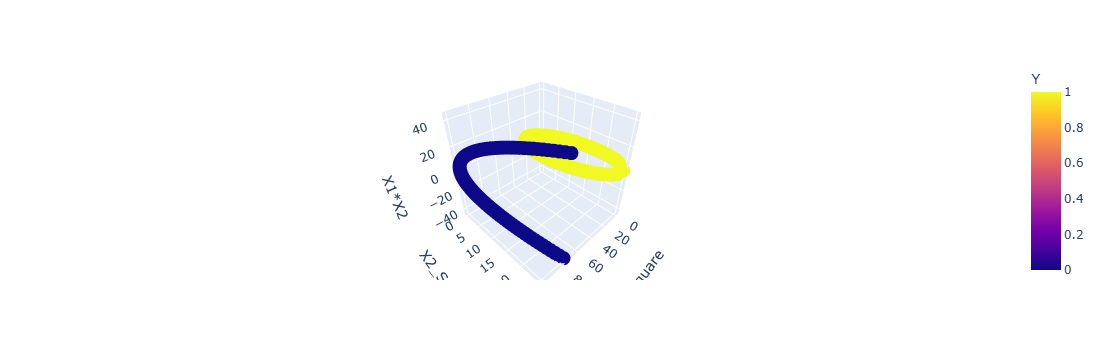

In [71]:
fig=px.scatter_3d(df2,x='X1_Square',y='X2_Square',z='X1*X2', color='Y')

fig.show()

This one looks like a hyperplane can split it.

In [72]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
classifier2=SVC(kernel='linear')
classifier2.fit(X_train2,y_train2)
y_pred2=classifier2.predict(X_test2)
accuracy_score(y_test2,y_pred2)

1.0

It has a perfect accuracy. This is because we manually transformed the data. Let us check if we just assign the kernel as polynomial directly, if the accuracy will be same 

In [81]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
classifier=SVC(kernel='poly')
classifier.fit(X_train,y_train)
y_pred=classifier.predict(X_test)
score=accuracy_score(y_test,y_pred)
print(score)
cm=confusion_matrix(y_test,y_pred)
print(cm)
print(classification_report(y_test,y_pred))

0.69
[[21 31]
 [ 0 48]]
              precision    recall  f1-score   support

           0       1.00      0.40      0.58        52
           1       0.61      1.00      0.76        48

    accuracy                           0.69       100
   macro avg       0.80      0.70      0.67       100
weighted avg       0.81      0.69      0.66       100



Not very good though. So this shows that sometimes we can do the transformation manually for better results 

#### RBF Kernel

In [80]:
from sklearn.metrics import classification_report, confusion_matrix
classifier_rbf=SVC(kernel='rbf')
classifier_rbf.fit(X_train,y_train)
y_pred=classifier_rbf.predict(X_test)
score=accuracy_score(y_test,y_pred)
print(score)
cm=confusion_matrix(y_test,y_pred)
print(cm)
print(classification_report(y_test,y_pred))

1.0
[[52  0]
 [ 0 48]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        52
           1       1.00      1.00      1.00        48

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



Ths is a perfect performance for rbf kernel. We will try sigmoid 

In [82]:
from sklearn.metrics import classification_report, confusion_matrix
classifier_sig=SVC(kernel='sigmoid')
classifier_sig.fit(X_train,y_train)
y_pred=classifier_sig.predict(X_test)
score=accuracy_score(y_test,y_pred)
print(score)
cm=confusion_matrix(y_test,y_pred)
print(cm)
print(classification_report(y_test,y_pred))

0.56
[[30 22]
 [22 26]]
              precision    recall  f1-score   support

           0       0.58      0.58      0.58        52
           1       0.54      0.54      0.54        48

    accuracy                           0.56       100
   macro avg       0.56      0.56      0.56       100
weighted avg       0.56      0.56      0.56       100



Sigmoid also has a very poor performance

## Support Vector Regression Implementation

In [1]:
## Dataset (Tips Dataset)
import seaborn as sns
tips_df=sns.load_dataset('tips')
tips_df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [2]:
tips_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [3]:
tips_df['sex'].value_counts()

sex
Male      157
Female     87
Name: count, dtype: int64

In [4]:
tips_df['smoker'].value_counts()

smoker
No     151
Yes     93
Name: count, dtype: int64

In [5]:
tips_df['day'].value_counts()

day
Sat     87
Sun     76
Thur    62
Fri     19
Name: count, dtype: int64

In [6]:
tips_df['time'].value_counts()

time
Dinner    176
Lunch      68
Name: count, dtype: int64

In [7]:
## Feature Encoding(Label Encoding and One-Hot-Encoding)
tips_df.columns

Index(['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size'], dtype='str')

In [8]:
X=tips_df[['total_bill','sex','smoker','day','time','size']]
y=tips_df['tip']

In [9]:
## train test split
## We split first because we do not want the model to have any information about the test data (avoid data leakage)
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=10)

In [10]:
X_train.head()

,total_bill,sex,smoker,day,time,size
58,11.24,Male,Yes,Sat,Dinner,2
1,10.34,Male,No,Sun,Dinner,3
2,21.01,Male,No,Sun,Dinner,3
68,20.23,Male,No,Sat,Dinner,2
184,40.55,Male,Yes,Sun,Dinner,2


In [11]:
## Feature Encoding (Label Encoding for binary classification)
from sklearn.preprocessing import LabelEncoder
le1=LabelEncoder()
le2=LabelEncoder()
le3=LabelEncoder()

In [12]:
## We perform them separately
import warnings
warnings.filterwarnings('ignore') ## We use this to prevent printing the unnecessary warnings
X_train['sex']=le1.fit_transform(X_train['sex'])
X_train['smoker']=le2.fit_transform(X_train['smoker'])
X_train['time']=le3.fit_transform(X_train['time'])

In [13]:
X_train.head()

,total_bill,sex,smoker,day,time,size
58,11.24,1,1,Sat,0,2
1,10.34,1,0,Sun,0,3
2,21.01,1,0,Sun,0,3
68,20.23,1,0,Sat,0,2
184,40.55,1,1,Sun,0,2


In [14]:
## we will do the same for the X_test data
X_test['sex']=le1.transform(X_test['sex'])
X_test['smoker']=le2.transform(X_test['smoker'])
X_test['time']=le3.transform(X_test['time'])

In [15]:
X_test.head()

,total_bill,sex,smoker,day,time,size
162,16.21,0,0,Sun,0,3
60,20.29,1,1,Sat,0,2
61,13.81,1,1,Sat,0,2
63,18.29,1,1,Sat,0,4
69,15.01,1,1,Sat,0,2


In [16]:
## Feature Encoding (One-Hot-Encoding for features with multiple categories)
## We will use ColumnTransformer

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [17]:
ct=ColumnTransformer(transformers=[('onehot',OneHotEncoder(drop='first'),['day'])], remainder='passthrough')

In [18]:
ct.fit_transform(X_train)

array([[1., 0., 0., ..., 1., 0., 2.],
       [0., 1., 0., ..., 0., 0., 3.],
       [0., 1., 0., ..., 0., 0., 3.],
       ...,
       [1., 0., 0., ..., 0., 0., 2.],
       [0., 0., 1., ..., 0., 1., 6.],
       [0., 1., 0., ..., 0., 0., 2.]], shape=(183, 8))

In [19]:
## To view it better
import sys
import numpy
numpy.set_printoptions(threshold=sys.maxsize)
X_train=ct.fit_transform(X_train)
X_train

array([[ 1.  ,  0.  ,  0.  , 11.24,  1.  ,  1.  ,  0.  ,  2.  ],
       [ 0.  ,  1.  ,  0.  , 10.34,  1.  ,  0.  ,  0.  ,  3.  ],
       [ 0.  ,  1.  ,  0.  , 21.01,  1.  ,  0.  ,  0.  ,  3.  ],
       [ 1.  ,  0.  ,  0.  , 20.23,  1.  ,  0.  ,  0.  ,  2.  ],
       [ 0.  ,  1.  ,  0.  , 40.55,  1.  ,  1.  ,  0.  ,  2.  ],
       [ 0.  ,  1.  ,  0.  ,  9.6 ,  0.  ,  1.  ,  0.  ,  2.  ],
       [ 0.  ,  1.  ,  0.  , 34.81,  0.  ,  0.  ,  0.  ,  4.  ],
       [ 0.  ,  0.  ,  1.  , 20.53,  1.  ,  1.  ,  1.  ,  4.  ],
       [ 0.  ,  0.  ,  1.  , 41.19,  1.  ,  0.  ,  1.  ,  5.  ],
       [ 1.  ,  0.  ,  0.  , 15.06,  0.  ,  0.  ,  0.  ,  2.  ],
       [ 1.  ,  0.  ,  0.  , 17.82,  1.  ,  0.  ,  0.  ,  2.  ],
       [ 0.  ,  1.  ,  0.  , 26.88,  1.  ,  0.  ,  0.  ,  4.  ],
       [ 0.  ,  0.  ,  1.  , 18.78,  0.  ,  0.  ,  0.  ,  2.  ],
       [ 1.  ,  0.  ,  0.  , 31.27,  1.  ,  0.  ,  0.  ,  3.  ],
       [ 0.  ,  0.  ,  1.  , 18.28,  1.  ,  0.  ,  1.  ,  2.  ],
       [ 1.  ,  0.  ,  0.

In [20]:
X_test=ct.transform(X_test) ## not fit_transform
X_test

array([[ 0.  ,  1.  ,  0.  , 16.21,  0.  ,  0.  ,  0.  ,  3.  ],
       [ 1.  ,  0.  ,  0.  , 20.29,  1.  ,  1.  ,  0.  ,  2.  ],
       [ 1.  ,  0.  ,  0.  , 13.81,  1.  ,  1.  ,  0.  ,  2.  ],
       [ 1.  ,  0.  ,  0.  , 18.29,  1.  ,  1.  ,  0.  ,  4.  ],
       [ 1.  ,  0.  ,  0.  , 15.01,  1.  ,  1.  ,  0.  ,  2.  ],
       [ 0.  ,  0.  ,  1.  , 32.68,  1.  ,  1.  ,  1.  ,  2.  ],
       [ 0.  ,  1.  ,  0.  , 19.49,  1.  ,  0.  ,  0.  ,  2.  ],
       [ 1.  ,  0.  ,  0.  , 25.89,  1.  ,  1.  ,  0.  ,  4.  ],
       [ 0.  ,  1.  ,  0.  , 22.23,  1.  ,  0.  ,  0.  ,  2.  ],
       [ 1.  ,  0.  ,  0.  , 24.06,  1.  ,  0.  ,  0.  ,  3.  ],
       [ 0.  ,  1.  ,  0.  , 23.33,  1.  ,  1.  ,  0.  ,  2.  ],
       [ 1.  ,  0.  ,  0.  , 44.3 ,  0.  ,  1.  ,  0.  ,  3.  ],
       [ 0.  ,  0.  ,  1.  ,  7.56,  1.  ,  0.  ,  1.  ,  2.  ],
       [ 1.  ,  0.  ,  0.  , 30.14,  0.  ,  1.  ,  0.  ,  4.  ],
       [ 0.  ,  1.  ,  0.  , 16.49,  1.  ,  0.  ,  0.  ,  4.  ],
       [ 0.  ,  0.  ,  1.

In [21]:
## Supoport Vector Regression
from sklearn.svm import SVR
svr=SVR()
svr.fit(X_train,y_train)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [22]:
y_pred = svr.predict(X_test)

In [23]:
from sklearn.metrics import r2_score, mean_absolute_error
print(r2_score(y_test,y_pred))
print(mean_absolute_error(y_test,y_pred))

0.4906520205317081
0.7032136104409814


In [24]:
## Hyperparameter Tuning usng GridSearchCV

from sklearn.model_selection import GridSearchCV
# define the parameter range
param_grid={'C': [0.1,1,10,100,1000],
            'gamma':[1,0.1,0.01,0.001,0.0001],
            'kernel':['rbf']}

In [25]:
grid=GridSearchCV(SVR(),param_grid,refit=True,verbose=3)

# fitting the model for grid search
grid.fit(X_train,y_train)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
[CV 1/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.043 total time=   0.0s
[CV 2/5] END .......C=0.1, gamma=1, kernel=rbf;, score=-0.003 total time=   0.0s
[CV 3/5] END .......C=0.1, gamma=1, kernel=rbf;, score=-0.145 total time=   0.0s
[CV 4/5] END .......C=0.1, gamma=1, kernel=rbf;, score=-0.064 total time=   0.0s
[CV 5/5] END .......C=0.1, gamma=1, kernel=rbf;, score=-0.073 total time=   0.0s
[CV 1/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.190 total time=   0.0s
[CV 2/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.088 total time=   0.0s
[CV 3/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.007 total time=   0.0s
[CV 4/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.120 total time=   0.0s
[CV 5/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.140 total time=   0.0s
[CV 1/5] END .....C=0.1, gamma=0.01, kernel=rbf;, score=0.193 total time=   0.0s
[CV 2/5] END .....C=0.1, gamma=0.01, kernel=rbf

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVR()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.1, 1, ...], 'gamma': [1, 0.1, ...], 'kernel': ['rbf']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and c

In [26]:
grid.best_params_

{'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}

In [27]:
grid_predictions = grid.predict(X_test)

In [28]:
print(r2_score(y_test,grid_predictions))
print(mean_absolute_error(y_test,grid_predictions))

0.31575739864936225
0.792356118540305


Investigate more. The performance is really poor